regression is a type of supervisied learrnig used to predict contunuos numerical value based on given input

ex- no,of hours increease the marks
house price prediction
salary prediction
-------experince increase salary incres


linear regression is type of ml algortihm used to predict the continuous numerical values using straight line releationship between input and output

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
hours=np.array([1,2,3,4,5,6,7,8,9,10])
scores=np.array([60,70,80,90,100,110,120,130,140,150])

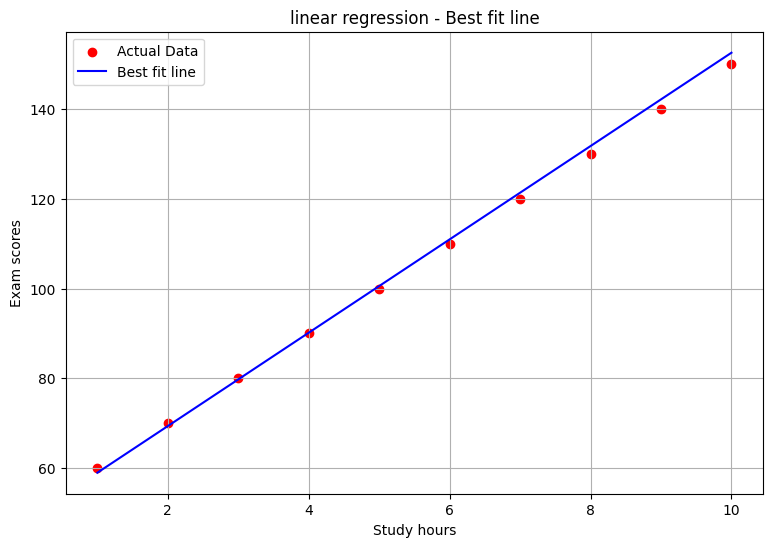

In [ ]:
predicted_score=10.41*hours+48.52
plt.figure(figsize=(9,6))
plt.scatter(hours,scores,label="Actual Data",color='red')
plt.plot(hours,predicted_score,label="Best fit line",color='blue')
plt.xlabel("Study hours")
plt.ylabel("Exam scores")
plt.title("linear regression - Best fit line")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
x=np.array([1,2,3,4,5],dtype=float)
y=np.array([60,70,80,90,100],dtype=float)
m=0
c=0
learning_rate=0.01
epochs=1000
n=len(x)
for i in range(epochs):
  y_pred=m*x+c
  error=y-y_pred
  mse=np.mean(error**2)
  dm=(-2/n)*np.sum(x*error)
  dc=(-2/n)*np.sum(error)
  m=m-(learning_rate*dm)
  c=c-(learning_rate*dc)
  if i%100==0:
    print(f'Epcoch{i}')
    print(f'MSE={mse:.2f}')
    print(f'm={m:.2f},c={c:.2f}')
    print('--------------------------------')
print("\n final best fit line ")
print(f"y={m:.2f}x+{c:.2f}")





Epcoch0
MSE=6600.00
m=5.20,c=1.60
--------------------------------
Epcoch100
MSE=177.90
m=18.63,c=18.84
--------------------------------
Epcoch200
MSE=90.37
m=16.15,c=27.79
--------------------------------
Epcoch300
MSE=45.90
m=14.38,c=34.17
--------------------------------
Epcoch400
MSE=23.32
m=13.12,c=38.72
--------------------------------
Epcoch500
MSE=11.84
m=12.23,c=41.96
--------------------------------
Epcoch600
MSE=6.02
m=11.59,c=44.27
--------------------------------
Epcoch700
MSE=3.06
m=11.13,c=45.92
--------------------------------
Epcoch800
MSE=1.55
m=10.81,c=47.09
--------------------------------
Epcoch900
MSE=0.79
m=10.57,c=47.93
--------------------------------

 final best fit line 
y=10.41x+48.52


**afternoon section**



In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LinearRegression
experience=np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15])
salary=np.array([35,38,42,48,55,60,65,70,76,82,87,92,96,100,105])

In [ ]:
x=experience.reshape(-1,1)

In [ ]:
y=salary
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
print(f'Training samples {len(x_train)}')
print(f'Testing samples {len(x_test)}')

Training samples 12
Testing samples 3


In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)
print(f'slope(coefficient):{model.coef_[0]:.2f}')
print(f'intercept:{model.intercept_:.2f}')
y_pred=model.predict(x_test)

for actual,predicted in zip(y_test,y_pred):
  print(f"Actual: {actual:>5} | Predicted: {predicted:>7.1f} | "
  f"Error: {predicted - actual:+.1f}")

slope(coefficient):5.22
intercept:27.94
Actual:    82 | Predicted:    80.2 | Error: -1.8
Actual:    92 | Predicted:    90.6 | Error: -1.4
Actual:    35 | Predicted:    33.2 | Error: -1.8


R² Score (R-Square)

“How well the model fits the data.”

Range:

0 to 1
1 → Perfect prediction
0 → Poor prediction

MAE calculates:

Average absolute difference between actual and predicted values.

RMSE measures prediction error but gives more importance to large errors.



In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
y_actual = np.array([500,300,700,450,600])
y_pred=np.array([480,320,690,460,590])

r2=r2_score(y_actual,y_pred)
mae=mean_absolute_error(y_actual,y_pred)
mse=mean_squared_error(y_actual,y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

print(f"R2 Score : {r2:.4f} -> model explains {r2*100:.1f}% of variance")
print(f"Mae : {mae:.1f} -> avg error + {mae:.0f} units")
print(f"RMSE : {rmse:.1f} -> penalised avg error {rmse:.0f} units")

R2 Score : 0.9880 -> model explains 98.8% of variance
Mae : 14.0 -> avg error + 14 units
RMSE : 14.8 -> penalised avg error 15 units


In [ ]:
#program 2

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
np.random.seed(42)
n = 100
data = pd.DataFrame({
 'experience': np.random.randint(0, 20, n),
 'education': np.random.randint(12, 20, n),
 'age': np.random.randint(22, 55, n),
})
data['salary'] = (
    data['experience']*45000+
    data['education']*2000+
    data['age']*300+
    np.random.normal(0,3000,n)
)

In [ ]:
x=data[['experience','education','age']]
y=data['salary']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)

for feat,coef in zip(x.columns,model.coef_):
  print(f"{feat:12s}:${coef:,.0f}per unit increase")
print(f" Base salary (intercept): ${model.intercept_:,.0f}")
y_pred=model.predict(x_test)
print(f'\nR:{r2_score(y_test,y_pred):.3f}')
print(f'MAE:${mean_absolute_error(y_test,y_pred):.3f}')




experience  :$45,034per unit increase
education   :$2,203per unit increase
age         :$266per unit increase
 Base salary (intercept): $-2,306

R:1.000
MAE:$2219.170
